In [2]:
!apt-get install openjdk-8-jdk-headless -qq > /dev/null
!wget -q http://archive.apache.org/dist/spark/spark-3.1.1/spark-3.1.1-bin-hadoop3.2.tgz
!tar xf spark-3.1.1-bin-hadoop3.2.tgz
!pip install -q findspark

In [3]:
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark-3.1.1-bin-hadoop3.2"

In [4]:
import findspark
findspark.init()
from pyspark import SparkContext, SparkConf, SQLContext
from pyspark.sql import SparkSession
#spark = SparkSession.builder.master("local[*]").getOrCreate()
spark = SparkSession.builder \
                    .master("local[*]") \
                    .appName("Ejemplo") \
                    .getOrCreate()
spark.conf.set("spark.sql.repl.eagerEval.enabled", True) # Property used to format output tables better
spark

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
#import kaggle as kg
import os
#import opendatasets as od
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
#kg.api.authenticate()
#kg.api.dataset_download_files('adarshsng/lending-club-loan-data-csv', path='C:/Users/jfmag/OneDrive/Documentos/Maestría/Big Data/KG_Data',unzip=True)

Dataset URL: https://www.kaggle.com/datasets/adarshsng/lending-club-loan-data-csv


In [7]:
#leemos el csv
df_original= spark.read.csv('/content/drive/MyDrive/Colab Notebooks/Big Data/KG_DATA/loan.csv',header=True, sep=",", inferSchema=True)
df_original.show(10)

+----+---------+---------+-----------+---------------+----------+--------+-----------+-----+---------+-------------------+----------+--------------+----------+-------------------+--------+-----------+----------+----+----+------------------+--------------------+--------+----------+-----+-----------+----------------+--------------+----------------------+----------------------+--------+-------+---------+----------+---------+-------------------+---------+-------------+-----------+---------------+---------------+-------------+------------------+----------+-----------------------+------------+---------------+------------+------------------+--------------------------+---------------------------+-----------+----------------+----------------+---------+-------------------------+--------------+------------+-----------+-----------+-----------+-----------+-----------+------------------+------------+-------+-----------+-----------+----------+--------+----------------+------+-----------+------------+

In [9]:
df_original.printSchema()

root
 |-- id: string (nullable = true)
 |-- member_id: string (nullable = true)
 |-- loan_amnt: integer (nullable = true)
 |-- funded_amnt: integer (nullable = true)
 |-- funded_amnt_inv: double (nullable = true)
 |-- term: string (nullable = true)
 |-- int_rate: double (nullable = true)
 |-- installment: double (nullable = true)
 |-- grade: string (nullable = true)
 |-- sub_grade: string (nullable = true)
 |-- emp_title: string (nullable = true)
 |-- emp_length: string (nullable = true)
 |-- home_ownership: string (nullable = true)
 |-- annual_inc: string (nullable = true)
 |-- verification_status: string (nullable = true)
 |-- issue_d: string (nullable = true)
 |-- loan_status: string (nullable = true)
 |-- pymnt_plan: string (nullable = true)
 |-- url: string (nullable = true)
 |-- desc: string (nullable = true)
 |-- purpose: string (nullable = true)
 |-- title: string (nullable = true)
 |-- zip_code: string (nullable = true)
 |-- addr_state: string (nullable = true)
 |-- dti: strin

In [10]:
df_original.count()

2260668

In [11]:
print(len(df_original.columns))

145


In [12]:
#contamos los nulos de todas las columnas
from pyspark.sql.functions import col, sum

#variable que almacena el 80% de la cantidad de filas
v80= df_original.count() * .8

# Contar valores nulos por columna
null_counts = df_original.select([sum(col(c).isNull().cast("int")).alias(c) for c in df_original.columns])

# Transponer el resultado
num_columns = len(df_original.columns)
transposed_null_counts = null_counts.selectExpr(f"stack({num_columns}, " + ", ".join([f"'{col}', {col}" for col in df_original.columns]) + ") as (column_name, null_count)")

#mostramos las columenas que tienen valores > 0
null_cols=transposed_null_counts.filter(transposed_null_counts.null_count>0)
print('Cantidad de campos con datos nulos: '+str(null_cols.count()))

#mostramos las columenas que tienen valores > 0
null_cols80=transposed_null_counts.filter(transposed_null_counts.null_count>v80)
print('Cantidad de campos con el 80% de datos nulos: ' + str(null_cols80.count()))

Cantidad de campos con datos nulos: 131
Cantidad de campos con el 80% de datos nulos: 39


In [8]:
from pyspark.sql.functions import regexp_replace, col

# Modificar la columna term antes de realizar el cast
df_original = df_original.withColumn("term", regexp_replace(col("term"), " months", "").cast("integer"))

# Lista de castings corregida, asegurándonos de que term es integer
columns_cast = [
    	'cast (loan_amnt as double) loan_amnt',
		'cast (member_id as string) member_id' ,
		'cast (id as string) id',
		'cast (funded_amnt as double) funded_amnt',
		'cast (funded_amnt_inv as double) funded_amnt_inv',
		'cast (term as integer) term',
		'cast (int_rate as double) int_rate',
		'cast (installment as double) installment',
		'cast (grade as string) grade',
		'cast (sub_grade as string) sub_grade',
		'cast (emp_title as string) emp_title',
		'cast (emp_length as string) emp_length',
		'cast (home_ownership as string) home_ownership',
		'cast (annual_inc as string) annual_inc',
		'cast (verification_status as string) verification_status',
		'cast (issue_d as string) issue_d',
		'cast (loan_status as string) loan_status',
		'cast (pymnt_plan as string) pymnt_plan',
		'cast (purpose as string) purpose',
		'cast (zip_code as string) zip_code',
		'cast (addr_state as string) addr_state',
		'cast (dti as double) dti',
		'cast (delinq_2yrs as string) delinq_2yrs',
		'cast (earliest_cr_line as string) earliest_cr_line',
		'cast (inq_last_6mths as string) inq_last_6mths',
		'cast (mths_since_last_delinq as integer) mths_since_last_delinq',
		'cast (mths_since_last_record as integer) mths_since_last_record',
		'cast (open_acc as integer) open_acc',
		'cast (pub_rec as string) pub_rec',
		'cast (revol_bal as double) revol_bal',
		'cast (revol_util as double) revol_util',
		'cast (total_acc as double) total_acc',
		'cast (initial_list_status as string) initial_list_status',
		'cast (out_prncp as double) out_prncp',
		'cast (out_prncp_inv as double) out_prncp_inv',
		'cast (total_pymnt as double) total_pymnt',
		'cast (total_pymnt_inv as double) total_pymnt_inv',
		'cast (total_rec_prncp as double) total_rec_prncp',
		'cast (total_rec_int as double) total_rec_int',
		'cast (total_rec_late_fee as double) total_rec_late_fee',
		'cast (recoveries as double) recoveries',
		'cast (collection_recovery_fee as double) collection_recovery_fee',
		'cast (last_credit_pull_d as string) last_credit_pull_d',
		'cast (last_pymnt_d as string) last_pymnt_d',
		'cast (last_pymnt_amnt as double) last_pymnt_amnt',
		'cast (next_pymnt_d as string) next_pymnt_d',
		'cast (collections_12_mths_ex_med as integer) collections_12_mths_ex_med',
		'cast (mths_since_last_major_derog as integer) mths_since_last_major_derog',
		'cast (policy_code as string) policy_code',
		'cast (application_type as string) application_type',
		'cast (annual_inc_joint as double) annual_inc_joint',
		'cast (dti_joint as double) dti_joint',
		'cast (verification_status_joint as string) verification_status_joint',
		'cast (acc_now_delinq as integer) acc_now_delinq',
		'cast (tot_coll_amt as double) tot_coll_amt',
		'cast (tot_cur_bal as double) tot_cur_bal',
		'cast (open_acc_6m as integer) open_acc_6m',
		'cast (open_act_il as integer) open_act_il',
		'cast (open_il_12m as integer) open_il_12m',
		'cast (open_il_24m as integer) open_il_24m',
		'cast (mths_since_rcnt_il as integer) mths_since_rcnt_il',
		'cast (total_bal_il as double) total_bal_il',
		'cast (il_util as double) il_util',
		'cast (open_rv_12m as integer) open_rv_12m',
		'cast (open_rv_24m as integer) open_rv_24m',
		'cast (max_bal_bc as double) max_bal_bc',
		'cast (all_util as integer) all_util',
		'cast (total_rev_hi_lim as double) total_rev_hi_lim',
		'cast (inq_fi as integer) inq_fi',
		'cast (total_cu_tl as integer) total_cu_tl',
		'cast (inq_last_12m as integer) inq_last_12m',
		'cast (acc_open_past_24mths as integer) acc_open_past_24mths',
		'cast (avg_cur_bal as double) avg_cur_bal',
		'cast (bc_open_to_buy as double) bc_open_to_buy',
		'cast (bc_util as double) bc_util',
		'cast (chargeoff_within_12_mths as integer) chargeoff_within_12_mths',
		'cast (delinq_amnt as double) delinq_amnt',
		'cast (mo_sin_old_il_acct as integer) mo_sin_old_il_acct',
		'cast (mo_sin_old_rev_tl_op as integer) mo_sin_old_rev_tl_op',
		'cast (mo_sin_rcnt_rev_tl_op as integer) mo_sin_rcnt_rev_tl_op',
		'cast (mo_sin_rcnt_tl as integer) mo_sin_rcnt_tl',
		'cast (mort_acc as integer) mort_acc',
		'cast (mths_since_recent_bc as integer) mths_since_recent_bc',
		'cast (mths_since_recent_bc_dlq as integer) mths_since_recent_bc_dlq',
		'cast (mths_since_recent_inq as integer) mths_since_recent_inq',
		'cast (mths_since_recent_revol_delinq as integer) mths_since_recent_revol_delinq',
		'cast (num_accts_ever_120_pd as integer) num_accts_ever_120_pd',
		'cast (num_actv_bc_tl as integer) num_actv_bc_tl',
		'cast (num_actv_rev_tl as integer) num_actv_rev_tl',
		'cast (num_bc_sats as integer) num_bc_sats',
		'cast (num_bc_tl as integer) num_bc_tl',
		'cast (num_il_tl as integer) num_il_tl',
		'cast (num_op_rev_tl as integer) num_op_rev_tl',
		'cast (num_rev_accts as integer) num_rev_accts',
		'cast (num_rev_tl_bal_gt_0 as integer) num_rev_tl_bal_gt_0',
		'cast (num_sats as integer) num_sats',
		'cast (num_tl_120dpd_2m as integer) num_tl_120dpd_2m',
		'cast (num_tl_30dpd as integer) num_tl_30dpd',
		'cast (num_tl_90g_dpd_24m as integer) num_tl_90g_dpd_24m',
		'cast (num_tl_op_past_12m as integer) num_tl_op_past_12m',
		'cast (pct_tl_nvr_dlq as double) pct_tl_nvr_dlq',
		'cast (percent_bc_gt_75 as double) percent_bc_gt_75',
		'cast (pub_rec_bankruptcies as integer) pub_rec_bankruptcies',
		'cast (tax_liens as integer) tax_liens',
		'cast (tot_hi_cred_lim as double) tot_hi_cred_lim',
		'cast (total_bal_ex_mort as double) total_bal_ex_mort',
		'cast (total_bc_limit as double) total_bc_limit',
		'cast (total_il_high_credit_limit as double) total_il_high_credit_limit',
		'cast (revol_bal_joint as double) revol_bal_joint',
		'cast (sec_app_earliest_cr_line as string) sec_app_earliest_cr_line',
		'cast (sec_app_inq_last_6mths as integer) sec_app_inq_last_6mths',
		'cast (sec_app_mort_acc as integer) sec_app_mort_acc',
		'cast (sec_app_open_acc as integer) sec_app_open_acc',
		'cast (sec_app_revol_util as double) sec_app_revol_util',
		'cast (sec_app_open_act_il as double) sec_app_open_act_il',
		'cast (sec_app_num_rev_accts as integer) sec_app_num_rev_accts',
		'cast (sec_app_chargeoff_within_12_mths as integer) sec_app_chargeoff_within_12_mths',
		'cast (sec_app_collections_12_mths_ex_med as integer) sec_app_collections_12_mths_ex_med',
		'cast (sec_app_mths_since_last_major_derog as integer) sec_app_mths_since_last_major_derog',
		'cast (hardship_flag as string) hardship_flag',
		'cast (hardship_type as string) hardship_type',
		'cast (hardship_reason as string) hardship_reason',
		'cast (hardship_status as string) hardship_status',
		'cast (deferral_term as integer) deferral_term',
		'cast (hardship_amount as double) hardship_amount',
		'cast (hardship_start_date as string) hardship_start_date',
		'cast (hardship_end_date as string) hardship_end_date',
		'cast (payment_plan_start_date as string) payment_plan_start_date',
		'cast (hardship_length as integer) hardship_length',
		'cast (hardship_dpd as integer) hardship_dpd',
		'cast (hardship_loan_status as string) hardship_loan_status',
		'cast (orig_projected_additional_accrued_interest as double) orig_projected_additional_accrued_interest',
		'cast (hardship_payoff_balance_amount as double) hardship_payoff_balance_amount',
		'cast (hardship_last_payment_amount as string) hardship_last_payment_amount',
		'cast (disbursement_method as string) disbursement_method',
		'cast (debt_settlement_flag as string) debt_settlement_flag',
		'cast (debt_settlement_flag_date as string) debt_settlement_flag_date',
		'cast (settlement_status as string) settlement_status',
		'cast (settlement_date as string) settlement_date',
		'cast (settlement_amount as double) settlement_amount',
		'cast (settlement_percentage as double) settlement_percentage',
		'cast (settlement_term as integer) settlement_term'
]

# Aplicamos la conversión sobre todo el DataFrame
df_loans = df_original.selectExpr(*columns_cast)

# Mostrar el resultado
df_loans.show()

+---------+---------+----+-----------+---------------+----+--------+-----------+-----+---------+--------------------+----------+--------------+----------+-------------------+--------+-----------+----------+------------------+--------+----------+-----+-----------+----------------+--------------+----------------------+----------------------+--------+-------+---------+----------+---------+-------------------+---------+-------------+-----------+---------------+---------------+-------------+------------------+----------+-----------------------+------------------+------------+---------------+------------+--------------------------+---------------------------+-----------+----------------+----------------+---------+-------------------------+--------------+------------+-----------+-----------+-----------+-----------+-----------+------------------+------------+-------+-----------+-----------+----------+--------+----------------+------+-----------+------------+--------------------+-----------+---

In [14]:
df_loans.printSchema()

root
 |-- loan_amnt: double (nullable = true)
 |-- member_id: string (nullable = true)
 |-- id: string (nullable = true)
 |-- funded_amnt: double (nullable = true)
 |-- funded_amnt_inv: double (nullable = true)
 |-- term: integer (nullable = true)
 |-- int_rate: double (nullable = true)
 |-- installment: double (nullable = true)
 |-- grade: string (nullable = true)
 |-- sub_grade: string (nullable = true)
 |-- emp_title: string (nullable = true)
 |-- emp_length: string (nullable = true)
 |-- home_ownership: string (nullable = true)
 |-- annual_inc: string (nullable = true)
 |-- verification_status: string (nullable = true)
 |-- issue_d: string (nullable = true)
 |-- loan_status: string (nullable = true)
 |-- pymnt_plan: string (nullable = true)
 |-- purpose: string (nullable = true)
 |-- zip_code: string (nullable = true)
 |-- addr_state: string (nullable = true)
 |-- dti: double (nullable = true)
 |-- delinq_2yrs: string (nullable = true)
 |-- earliest_cr_line: string (nullable = true

In [9]:
string_columns = [col.name for col in df_loans.schema.fields if col.dataType.simpleString() == 'string']
numeric_columns = [col.name for col in df_loans.schema.fields if col.dataType.simpleString() != 'string']

df_strings = df_loans.select(string_columns)
df_numerics = df_loans.select(numeric_columns)


In [10]:
df_strings.show(10)
df_numerics.show(10)

+---------+----+-----+---------+-------------------+----------+--------------+----------+-------------------+--------+-----------+----------+------------------+--------+----------+-----------+----------------+--------------+-------+-------------------+------------------+------------+------------+-----------+----------------+-------------------------+------------------------+-------------+-------------+---------------+---------------+-------------------+-----------------+-----------------------+--------------------+----------------------------+-------------------+--------------------+-------------------------+-----------------+---------------+
|member_id|  id|grade|sub_grade|          emp_title|emp_length|home_ownership|annual_inc|verification_status| issue_d|loan_status|pymnt_plan|           purpose|zip_code|addr_state|delinq_2yrs|earliest_cr_line|inq_last_6mths|pub_rec|initial_list_status|last_credit_pull_d|last_pymnt_d|next_pymnt_d|policy_code|application_type|verification_status_joi

In [11]:
print(len(df_strings.columns))
print(len(df_numerics.columns))

41
101


In [12]:
df_pd_str= df_strings.drop('member_id').drop('id').limit(5000).toPandas()

In [14]:
df_pd_num= df_numerics.limit(5000).toPandas()

/content/spark-3.1.1-bin-hadoop3.2/python/pyspark/sql/pandas/conversion.py:186: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[column_name] = series


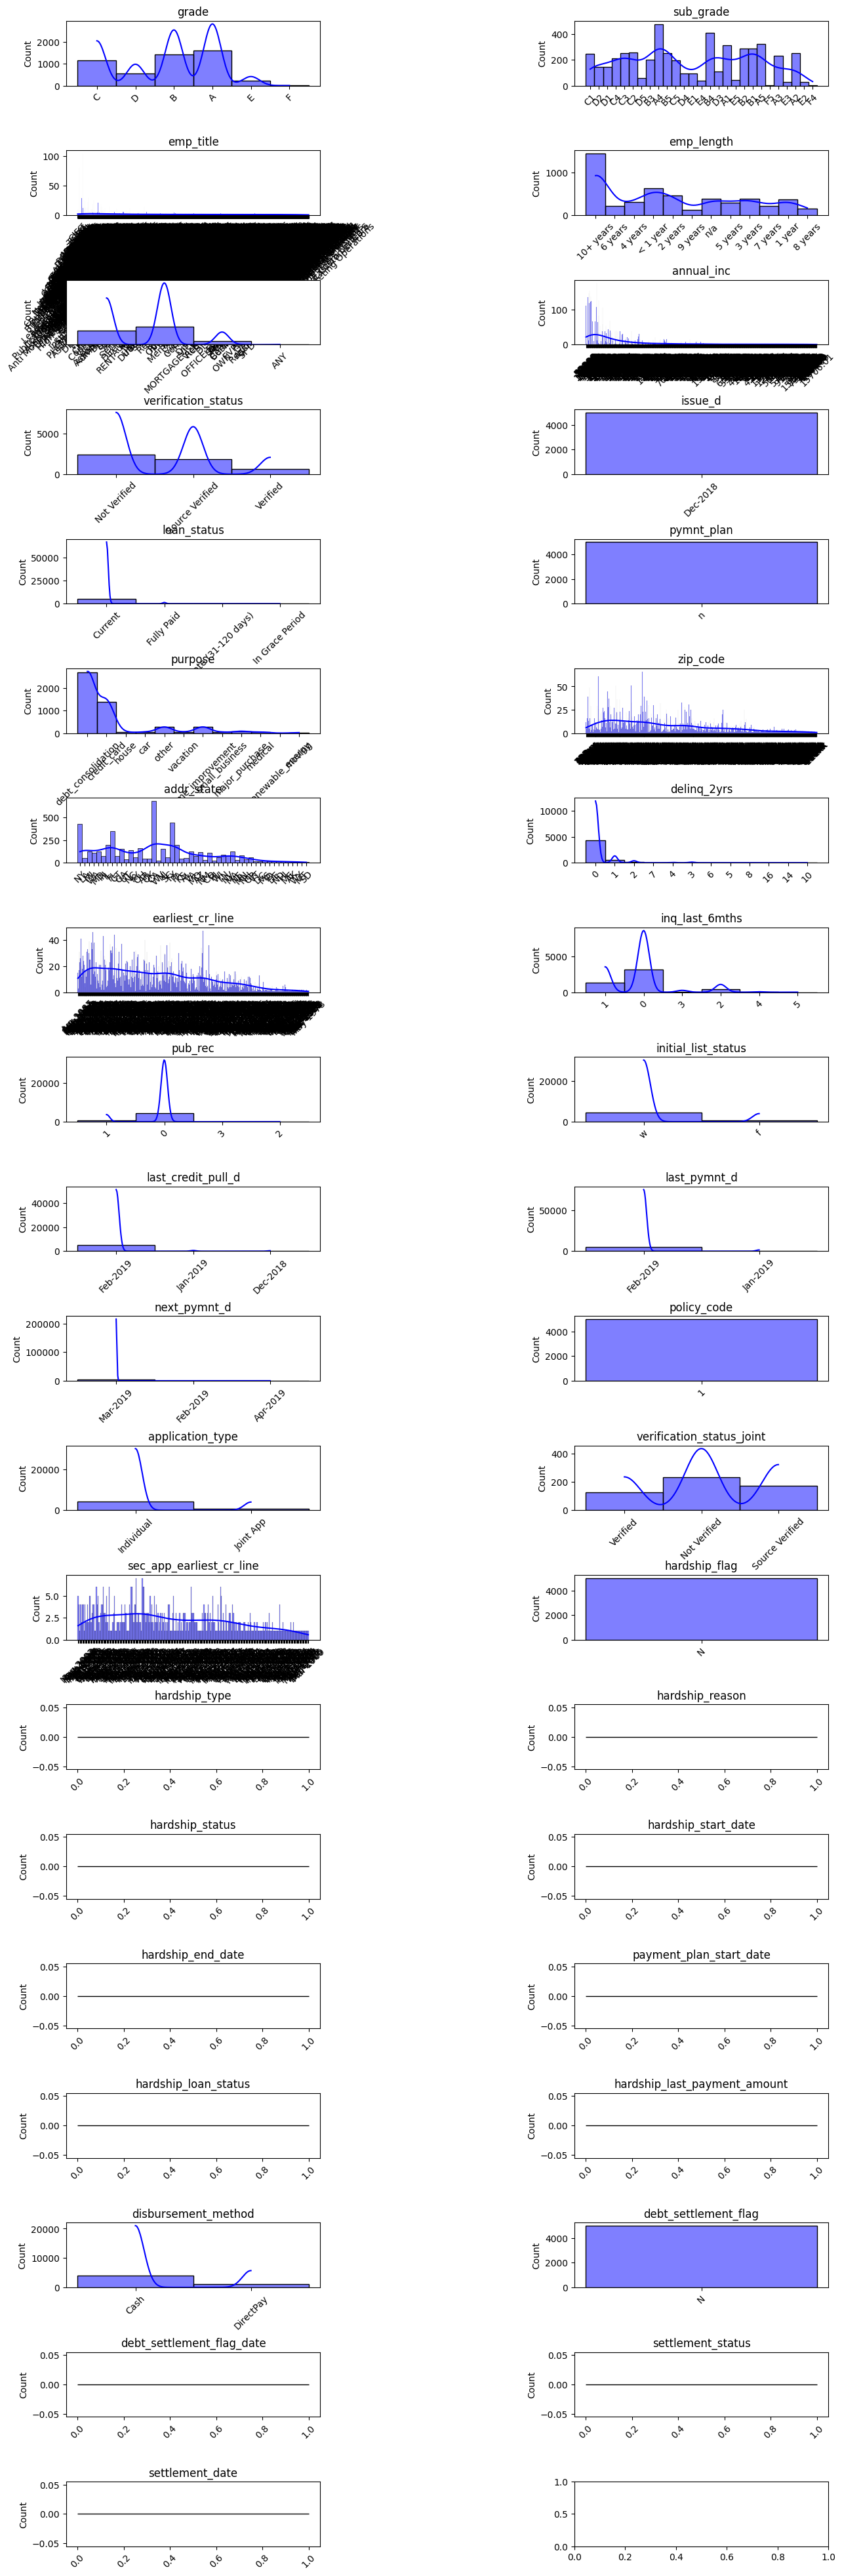

In [28]:
import math

num_columns = len(df_pd_str.columns)  # Total de columnas
rows = math.ceil(num_columns / 2)  # 2 columnas por fila

fig, axes = plt.subplots(rows, 2, figsize=(15, rows * 2.5))  # Ajuste automático
plt.subplots_adjust(wspace=1, hspace=1)
axes = axes.ravel()

for col, ax in zip(df_pd_str.columns, axes):
    sns.histplot(data=df_pd_str, x=col, kde=True, ax=ax, color="blue")
    ax.set(title=f'{col}', xlabel=None)
    ax.tick_params(axis='x', rotation=45)

plt.show()

In [29]:
df_pd_num1 = df_pd_num[['loan_amnt',
'funded_amnt',
'funded_amnt_inv',
'term',
'int_rate',
'installment',
'dti', #removed extra space
'mths_since_last_delinq',
'mths_since_last_record',
'open_acc',
'revol_bal',
'revol_util',
'total_acc',
'out_prncp',
'out_prncp_inv',
'total_pymnt',
'total_pymnt_inv',
'total_rec_prncp',
'total_rec_int',
'total_rec_late_fee',
'recoveries',
'collection_recovery_fee',
'last_pymnt_amnt',
'collections_12_mths_ex_med',
'mths_since_last_major_derog',
'annual_inc_joint',
'dti_joint',
'acc_now_delinq',
'tot_coll_amt',
'tot_cur_bal',
'open_acc_6m',
'open_act_il',
'open_il_12m',
'open_il_24m']] # Added extra brackets to select multiple columns

df_pd_num2 = df_pd_num[['mths_since_rcnt_il',
'total_bal_il',
'il_util',
'open_rv_12m',
'open_rv_24m',
'max_bal_bc',
'all_util',
'total_rev_hi_lim',
'inq_fi',
'total_cu_tl',
'inq_last_12m',
'acc_open_past_24mths',
'avg_cur_bal',
'bc_open_to_buy',
'bc_util',
'chargeoff_within_12_mths',
'delinq_amnt',
'mo_sin_old_il_acct',
'mo_sin_old_rev_tl_op',
'mo_sin_rcnt_rev_tl_op',
'mo_sin_rcnt_tl',
'mort_acc',
'mths_since_recent_bc',
'mths_since_recent_bc_dlq',
'mths_since_recent_inq',
'mths_since_recent_revol_delinq',
'num_accts_ever_120_pd',
'num_actv_bc_tl',
'num_actv_rev_tl',
'num_bc_sats',
'num_bc_tl',
'num_il_tl',
'num_op_rev_tl',
'num_rev_accts']] # Added extra brackets to select multiple columns

df_pd_num3 = df_pd_num[['num_rev_tl_bal_gt_0',
'num_sats',
'num_tl_120dpd_2m',
'num_tl_30dpd',
'num_tl_90g_dpd_24m',
'num_tl_op_past_12m',
'pct_tl_nvr_dlq',
'percent_bc_gt_75',
'pub_rec_bankruptcies',
'tax_liens',
'tot_hi_cred_lim',
'total_bal_ex_mort',
'total_bc_limit',
'total_il_high_credit_limit',
'revol_bal_joint',
'sec_app_inq_last_6mths',
'sec_app_mort_acc',
'sec_app_open_acc',
'sec_app_revol_util',
'sec_app_open_act_il',
'sec_app_num_rev_accts',
'sec_app_chargeoff_within_12_mths',
'sec_app_collections_12_mths_ex_med',
'sec_app_mths_since_last_major_derog',
'deferral_term',
'hardship_amount',
'hardship_length',
'hardship_dpd',
'orig_projected_additional_accrued_interest',
'hardship_payoff_balance_amount',
'settlement_amount',
'settlement_percentage',
'settlement_term']] # Added extra brackets to select multiple columns

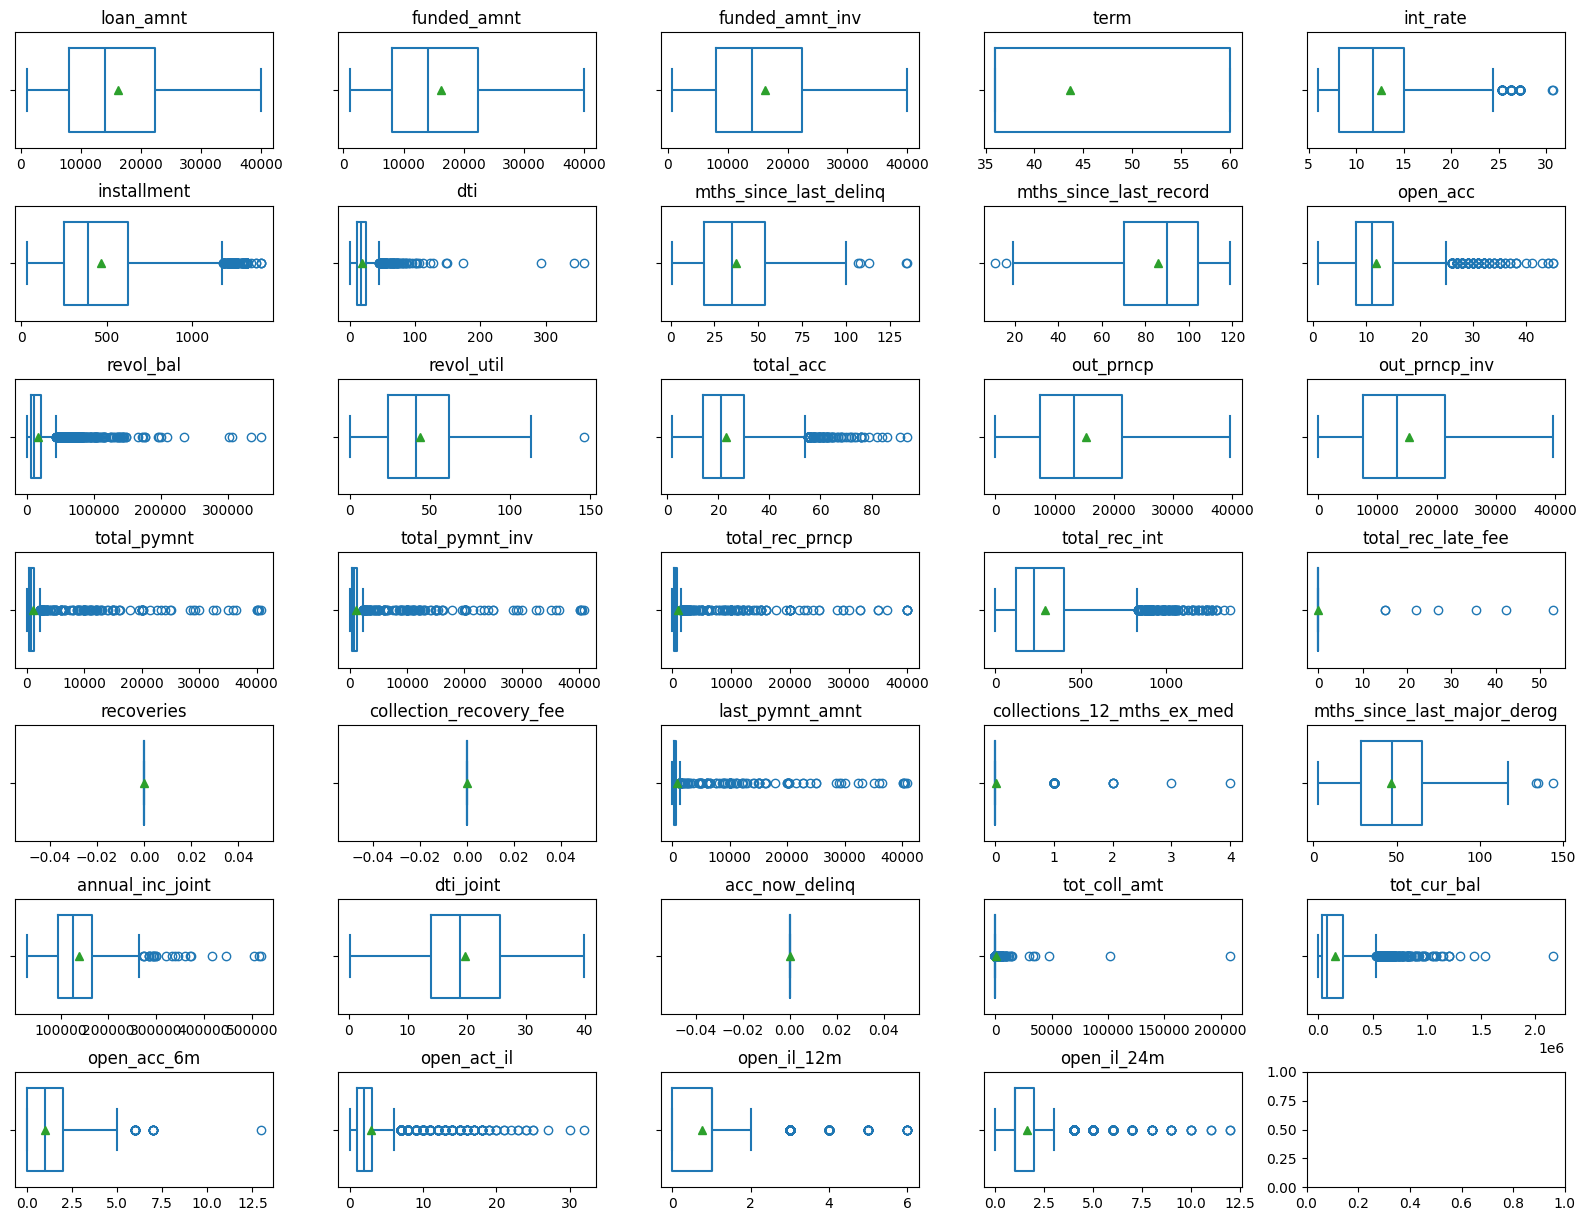

In [23]:
fig, axes = plt.subplots(7, 5, figsize=(20, 15))  # Ajusta filas y columnas
plt.subplots_adjust(wspace=0.25, hspace=0.5)
axes = axes.ravel()

for col, ax in zip(df_pd_num1, axes):
  sns.boxplot(data=df_pd_num1,x=col, ax=ax, showmeans=True, gap=.1, fill=False)
  ax.set(title=f'{col}', xlabel=None)

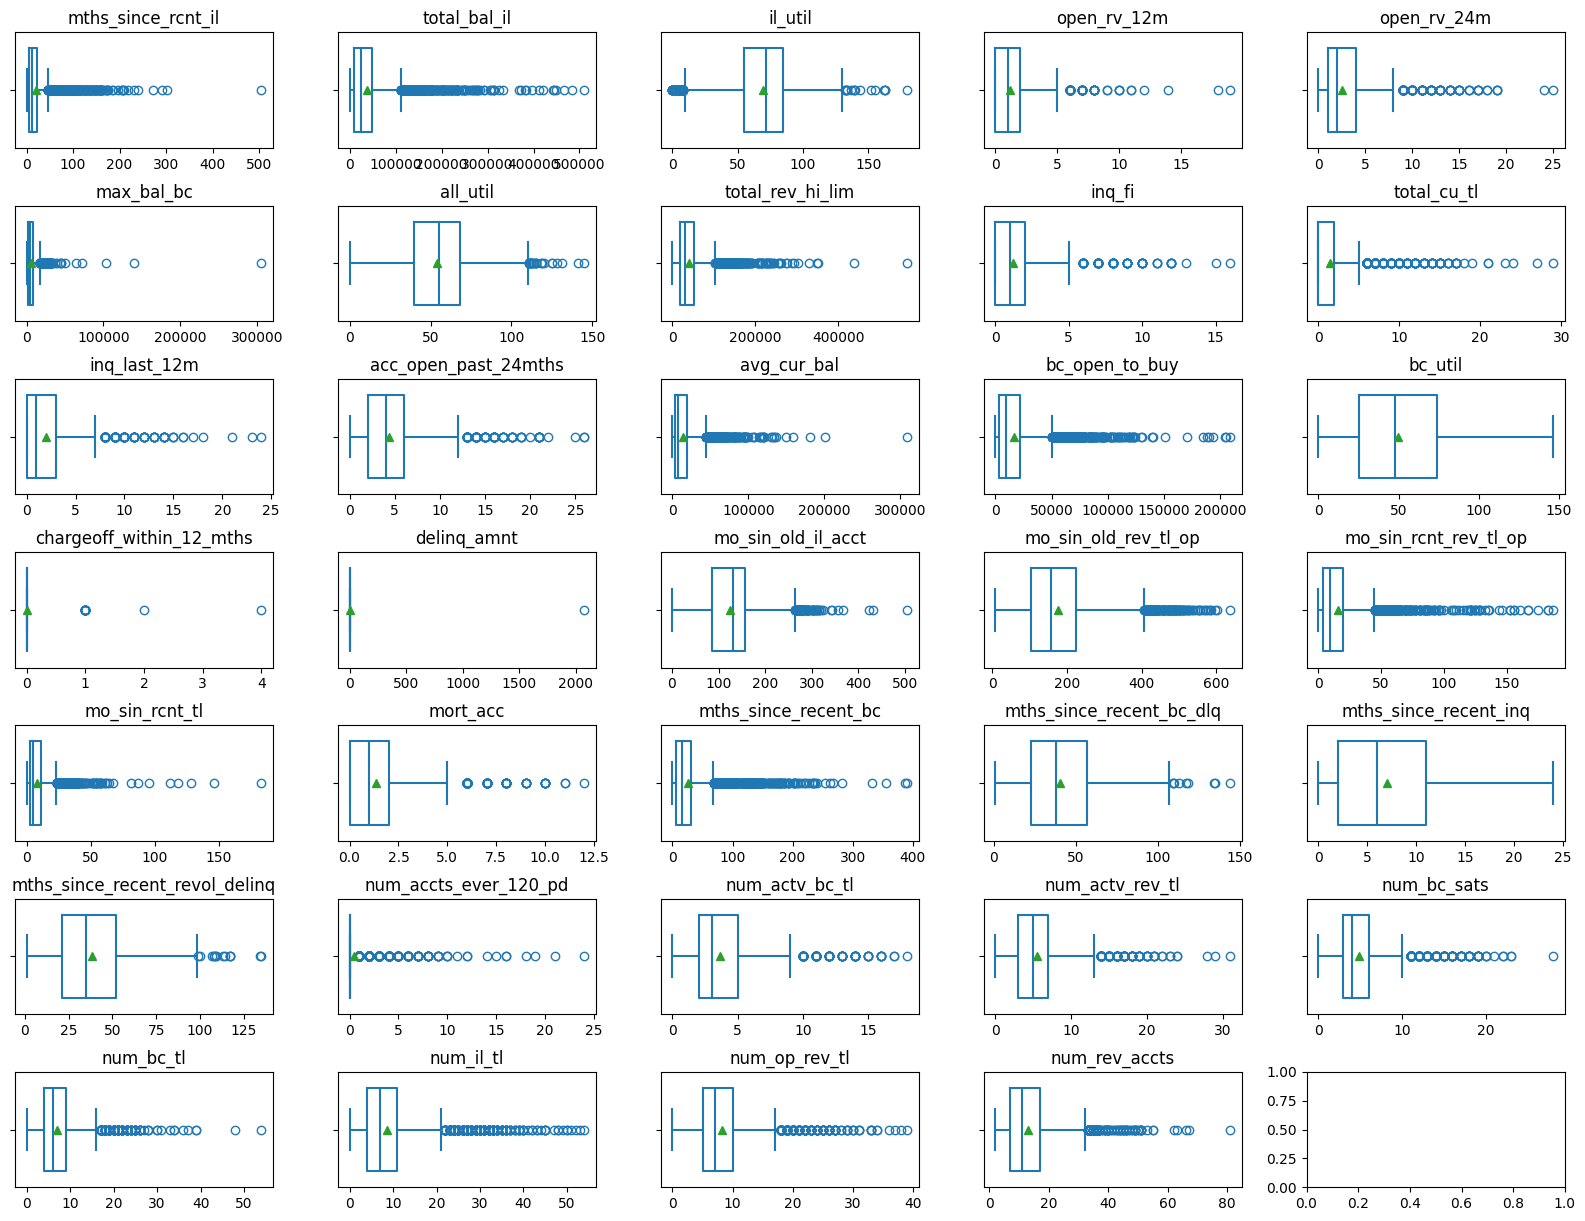

In [24]:
fig, axes = plt.subplots(7, 5, figsize=(20, 15))  # Ajusta filas y columnas
plt.subplots_adjust(wspace=0.25, hspace=0.5)
axes = axes.ravel()

for col, ax in zip(df_pd_num2, axes):
  sns.boxplot(data=df_pd_num2,x=col, ax=ax, showmeans=True, gap=.1, fill=False)
  ax.set(title=f'{col}', xlabel=None)

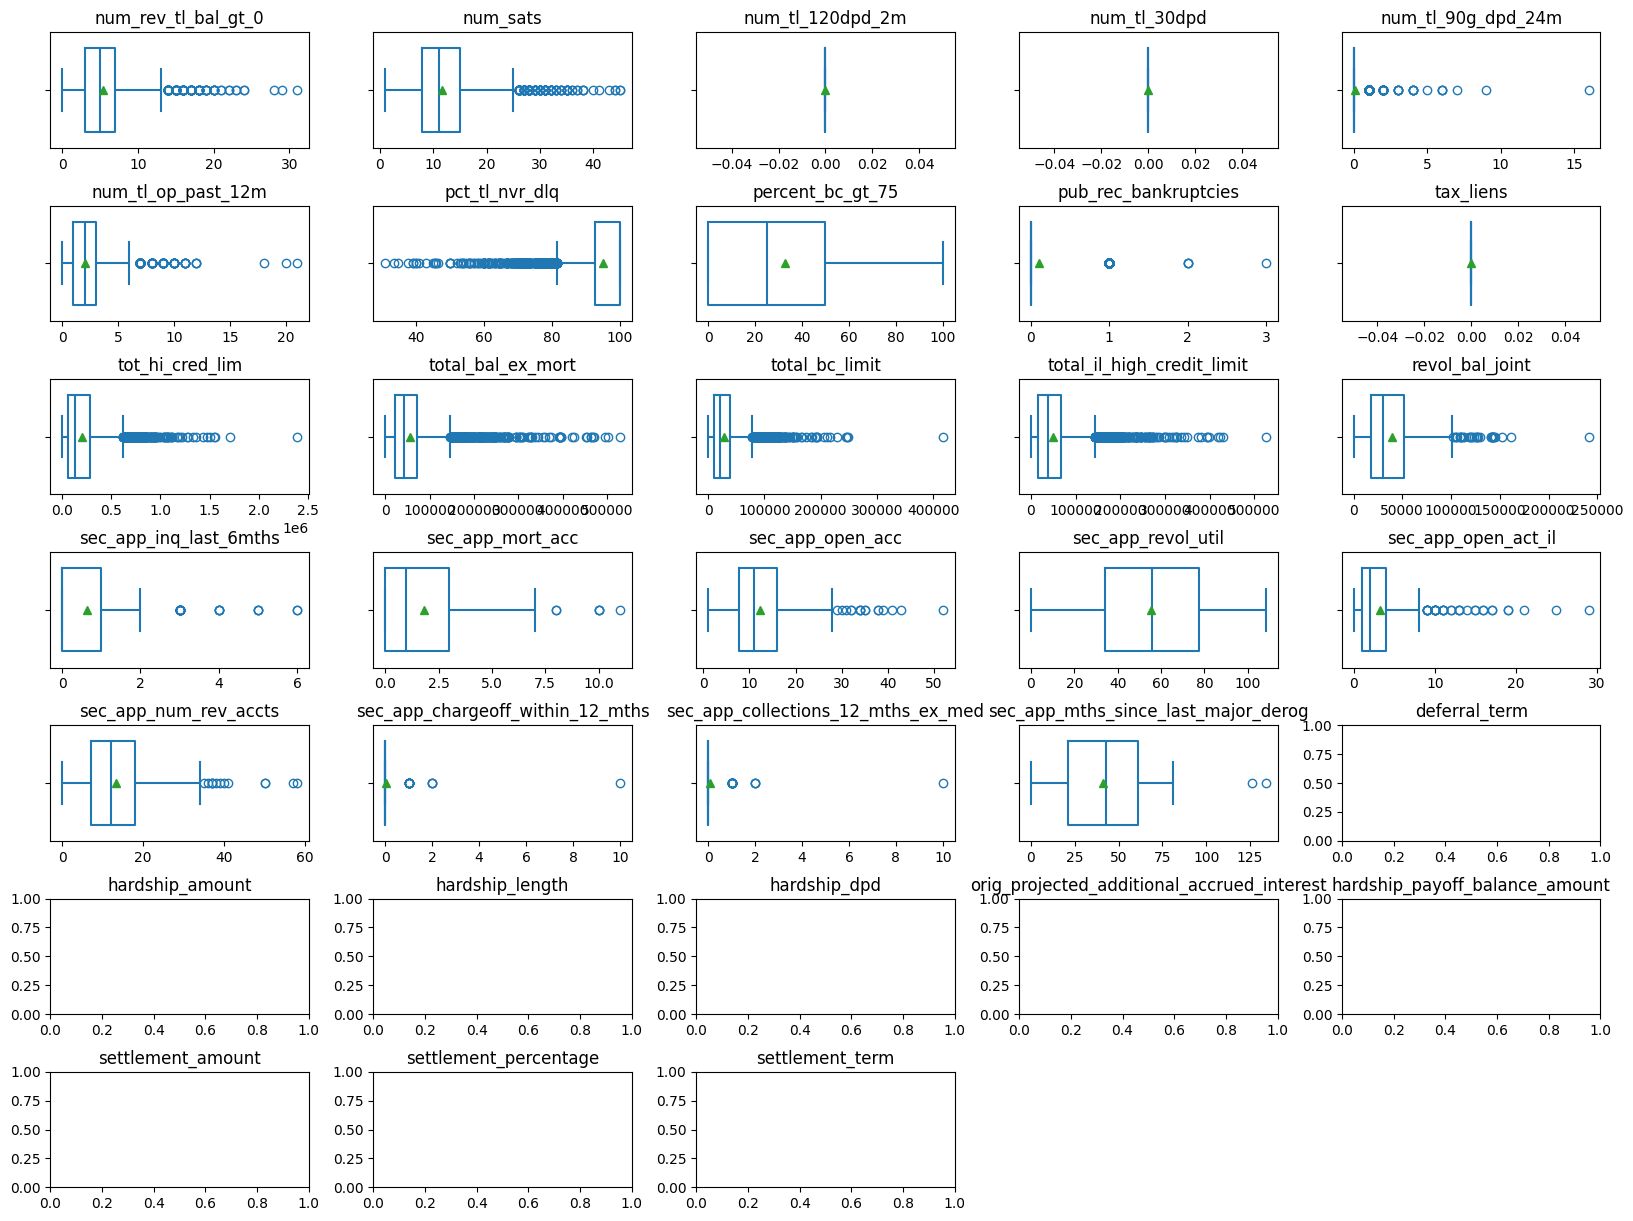

In [30]:
fig, axes = plt.subplots(7, 5, figsize=(20, 15))  # Ajusta filas y columnas
plt.subplots_adjust(wspace=0.25, hspace=0.5)
axes = axes.ravel()

# Get the number of columns in the DataFrame
num_cols = len(df_pd_num3.columns)

# Iterate only through the available columns and axes
for i in range(min(num_cols, len(axes))):
    col = df_pd_num3.columns[i]
    ax = axes[i]
    # Drop missing values before plotting
    sns.boxplot(data=df_pd_num3.dropna(subset=[col]), x=col, ax=ax, showmeans=True, gap=.1, fill=False)
    ax.set(title=f'{col}', xlabel=None)

# Hide any unused axes
for i in range(num_cols, len(axes)):
    axes[i].set_visible(False)

plt.show()